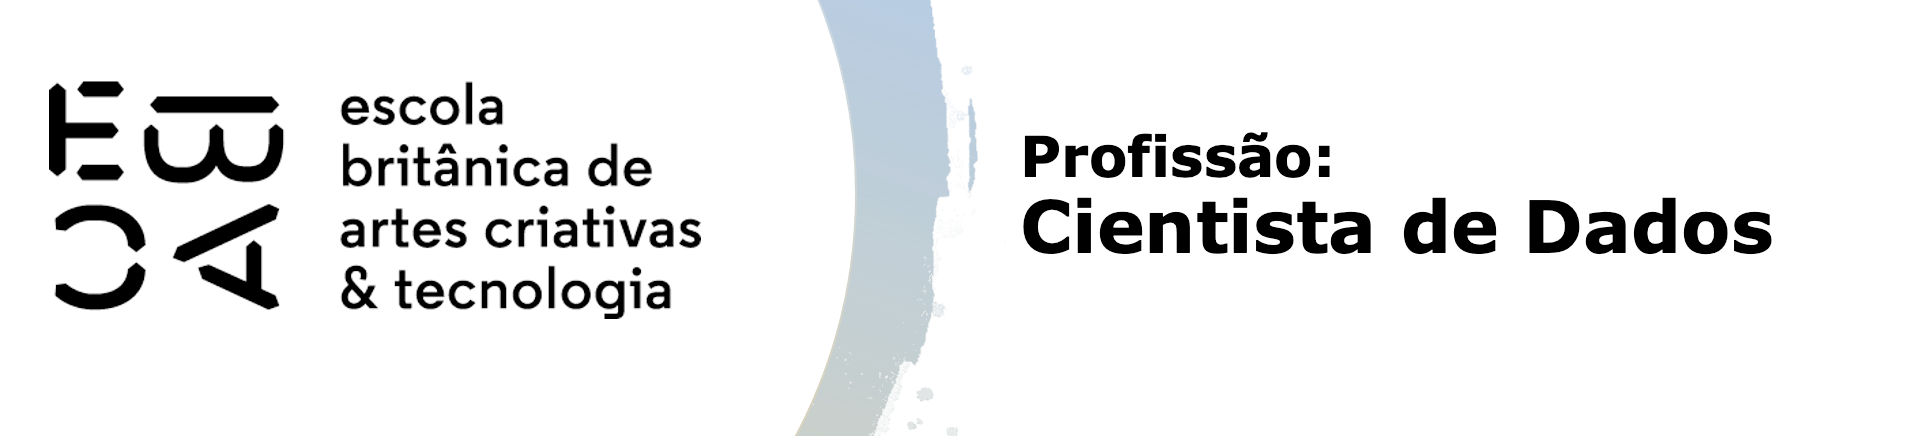

# Tarefa I

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [200]:
# Importa as bibliotecas necessárias para análise de dados, visualização e modelagem estatística
import pandas as pd                # Manipulação de dados em DataFrames
import numpy as np                 # Operações numéricas e arrays
import matplotlib.pyplot as plt    # Visualização de dados (gráficos)
import seaborn as sns              # Visualização de dados estatísticos (gráficos avançados)
from IPython.display import display, HTML  # Exibição de tabelas e HTML no Jupyter Notebook
import statsmodels.formula.api as smf      # Modelagem estatística (regressão, etc) usando fórmulas
import statsmodels.api as sm               # Modelagem estatística (funções gerais)
from scipy.stats import t
from statsmodels.graphics.regressionplots import influence_plot
from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant
from patsy import dmatrix

from sklearn import metrics
from scipy.stats import ks_2samp

# Carrega a base de dados credit_scoring.ftr em um DataFrame
# O arquivo deve estar no caminho especificado. O formato .ftr é eficiente para leitura/escrita de grandes volumes de dados.
df_original = pd.read_feather('credit_scoring.ftr')

In [201]:
pd.set_option('display.max_columns', None)

In [202]:
def atualizar_metadados(df):
    # Cria um DataFrame com os tipos de dados das colunas
    metadados = pd.DataFrame(df.dtypes, columns=['dtype'])
    
    # Adiciona uma coluna com o número de valores ausentes (missings) por variável
    metadados['n_missings'] = df.isna().sum()
    
    # Adiciona uma coluna com o número de valores únicos por variável
    metadados['Valores únicos'] = df.nunique()
    
    # Remove as variáveis 'data_ref' e 'index' do DataFrame de metadados, pois não são explicativas
    metadados = metadados.drop(['data_ref', 'index'], axis=0)
    
    # Retorna o DataFrame de metadados
    return metadados

def poder_de_predicao(df, modelo):
    # Cria uma cópia do DataFrame para evitar alterações no original
    df2 = df.copy()

    # Gera os scores (probabilidades preditas) usando o modelo fornecido
    df2['score'] = modelo.predict(df2)

    # Calcula a acurácia usando um threshold fixo (.068) para classificar como 'mau'
    acc = metrics.accuracy_score(df2.mau, df2.score > .068)

    # Calcula a curva ROC e a área sob a curva (AUC)
    fpr, tpr, thresholds = metrics.roc_curve(df2.mau, df2.score)
    auc = metrics.auc(fpr, tpr)

    # Calcula o Gini (2*AUC - 1)
    gini = 2 * auc - 1

    # Calcula o KS (Kolmogorov-Smirnov) entre scores dos maus e não maus
    ks = ks_2samp(df2.loc[df2.mau == 1, 'score'], df2.loc[df2.mau != 1, 'score']).statistic

    # Exibe as métricas formatadas
    print('Acurácia: {0:.1%} \nauc: {1:.1%} \nGINI: {2:.1%}\nKS: {3:.1%}'.format(acc, auc, gini, ks))
    
# Função para criar dataframe VIF e realizar a filtragem de variáveis que possuírem um valor acima do estipulado nos parâmetros
def vif_filter(X, limite=10):
    """
    Filtra variáveis com alto fator de inflação de variância (VIF) de um DataFrame.

    Parâmetros:
    X (pd.DataFrame): DataFrame contendo apenas variáveis numéricas independentes.
    limite (float): Valor limite de VIF para remoção de variáveis (padrão=10).

    Retorna:
    X_filtrado (pd.DataFrame): DataFrame com variáveis remanescentes após filtragem.
    removed_features (list): Lista de tuplas (variável, VIF) removidas.
    remaining_vif (pd.DataFrame): DataFrame com VIF das variáveis remanescentes.
    """
    X_filtrado = X.copy()  # Cria uma cópia do DataFrame original
    removed_features = []  # Lista para armazenar variáveis removidas
    vif_scores = {}        # Dicionário para armazenar os VIFs

    while True:
        # Adiciona constante para cálculo do VIF
        X_with_const = add_constant(X_filtrado)

        # Calcula o VIF para cada variável (incluindo a constante)
        vif_data = pd.DataFrame()
        vif_data["feature"] = X_with_const.columns
        vif_data["VIF"] = [vif(X_with_const.values, i)
                           for i in range(X_with_const.shape[1])]

        # Remove a constante da análise
        vif_data = vif_data[vif_data['feature'] != 'const']

        # Salva os VIFs calculados
        for _, row in vif_data.iterrows():
            vif_scores[row['feature']] = row['VIF']

        # Verifica o maior VIF
        max_vif = vif_data['VIF'].max()
        if max_vif <= limite:
            break  # Sai do loop se todos os VIFs estiverem abaixo do limite

        # Remove a variável com maior VIF
        feature_to_remove = vif_data.loc[vif_data['VIF'].idxmax(), 'feature']
        removed_features.append((feature_to_remove, max_vif))
        X_filtrado = X_filtrado.drop(columns=[feature_to_remove])

        # Se todas as variáveis forem removidas, lança erro
        if X_filtrado.shape[1] == 0:
            raise ValueError("Todas as variáveis foram removidas - limite pode estar muito baixo")

    # Monta DataFrame final com VIF das variáveis remanescentes
    remaining_vif = vif_data[vif_data['feature'].isin(X_filtrado.columns)]
    remaining_vif = remaining_vif.sort_values('VIF', ascending=False)

    return X_filtrado, removed_features, remaining_vif

def proporcao_de_categorias(dataframe, var, comparar=False):
    # Se comparar for False, calcula a frequência e percentual de uma variável em um dataframe
    if comparar == False:
        contagem = pd.crosstab(index=dataframe[var], columns="Frequência")
        contagem.sort_values(by="Frequência", ascending=False, inplace=True)
        contagem["pct_freq"] = (contagem['Frequência'] / contagem['Frequência'].sum()) * 100
        contagem.sort_values(by='Frequência', ascending=False, inplace=True)
        
        # Exibe a tabela formatada no notebook
        display(HTML(contagem.to_html(index=True, border=1, justify="center", bold_rows=True)))
        return contagem
    
    # Se comparar for True e o dataframe for uma lista, compara a distribuição da variável entre vários dataframes
    if comparar and isinstance(dataframe, list):
        resultados = []
        lista_html = []
        for df in dataframe:
            tab = pd.crosstab(index=df[var], columns="Frequência")
            tab.sort_values(by="Frequência", ascending=False, inplace=True)
            tab["pct_freq"] = (tab['Frequência'] / tab['Frequência'].sum()) * 100
            tab.sort_values(by='Frequência', ascending=False, inplace=True)
            
            resultados.append(tab)
            lista_html.append(tab.to_html(index=True, border=1, justify="center", bold_rows=True))
        
        # Exibe as tabelas lado a lado para comparação
        return display(HTML("<br><br>".join(lista_html)))

def biv_discreta(var, df):
    
    if type(var) != list:
        # Cria uma coluna 'bom' como o complemento de 'mau' (1-mau), para facilitar os cálculos
        df['bom'] = 1 - df.mau

        # Agrupa o DataFrame pela variável categórica de interesse
        g = df.groupby(item)

        # Monta um DataFrame com estatísticas bivariadas para cada categoria da variável
        biv = pd.DataFrame({
            'qt_bom': g['bom'].sum(),            # Quantidade de bons em cada categoria
            'qt_mau': g['mau'].sum(),            # Quantidade de maus em cada categoria
            'mau': g['mau'].mean(),              # Taxa de maus em cada categoria
            item: g['mau'].mean().index,          # Nome da categoria
            'cont': g[item].count()               # Contagem de registros em cada categoria
        })

        # Calcula o erro padrão da taxa de maus para cada categoria
        biv['ep'] = (biv.mau * (1 - biv.mau) / biv.cont) ** .5

        # Calcula o intervalo de confiança superior e inferior para a taxa de maus
        biv['mau_sup'] = biv.mau + t.ppf([0.975], biv.cont - 1) * biv.ep
        biv['mau_inf'] = biv.mau + t.ppf([0.025], biv.cont - 1) * biv.ep

        # Calcula o logit (log das odds) da taxa de maus e seus limites
        biv['logit'] = np.log(biv.mau / (1 - biv.mau))
        biv['logit_sup'] = np.log(biv.mau_sup / (1 - biv.mau_sup))
        biv['logit_inf'] = np.log(biv.mau_inf / (1 - biv.mau_inf))

        # Calcula o Weight of Evidence (WOE) para cada categoria
        tx_mau_geral = df.mau.mean()
        woe_geral = np.log(tx_mau_geral / (1 - tx_mau_geral))
        biv['woe'] = biv.logit - woe_geral
        biv['woe_sup'] = biv.logit_sup - woe_geral
        biv['woe_inf'] = biv.logit_inf - woe_geral
        
        categorias = {cat: i for i, cat in enumerate(biv[item].unique())}
        x_vals = biv[var].map(categorias)

        # Plota o WOE e seus limites para cada categoria
        fig, ax = plt.subplots(2, 1, figsize=(8, 6))
        ax[0].plot(x_vals, biv.woe, ':bo', label='woe')
        ax[0].plot(x_vals, biv.woe_sup, 'o:r', label='limite superior')
        ax[0].plot(x_vals, biv.woe_inf, 'o:r', label='limite inferior')

        # Ajusta os limites e rótulos do gráfico
        num_cat = biv.shape[0]
        ax[0].set_xlim([-.3, num_cat - .7])
        ax[0].set_ylabel("Weight of Evidence")
        ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
        ax[0].set_xticks(list(categorias.values()))
        ax[0].set_xticklabels(list(categorias.keys()), rotation=15)

        # Plota a contagem de registros por categoria
        ax[1] = biv.cont.plot.bar()
        
        return biv
    
    if type(var) == list:
        lista_html = []
        lista = var
        
        for item in lista:
                # Cria uma coluna 'bom' como o complemento de 'mau' (1-mau), para facilitar os cálculos
            df['bom'] = 1 - df.mau

            # Agrupa o DataFrame pela variável categórica de interesse
            g = df.groupby(item)

            # Monta um DataFrame com estatísticas bivariadas para cada categoria da variável
            biv = pd.DataFrame({
                'qt_bom': g['bom'].sum(),            # Quantidade de bons em cada categoria
                'qt_mau': g['mau'].sum(),            # Quantidade de maus em cada categoria
                'mau': g['mau'].mean(),              # Taxa de maus em cada categoria
                item: g['mau'].mean().index,          # Nome da categoria
                'cont': g[item].count()               # Contagem de registros em cada categoria
            })

            # Calcula o erro padrão da taxa de maus para cada categoria
            biv['ep'] = (biv.mau * (1 - biv.mau) / biv.cont) ** .5

            # Calcula o intervalo de confiança superior e inferior para a taxa de maus
            biv['mau_sup'] = biv.mau + t.ppf([0.975], biv.cont - 1) * biv.ep
            biv['mau_inf'] = biv.mau + t.ppf([0.025], biv.cont - 1) * biv.ep

            # Calcula o logit (log das odds) da taxa de maus e seus limites
            biv['logit'] = np.log(biv.mau / (1 - biv.mau))
            biv['logit_sup'] = np.log(biv.mau_sup / (1 - biv.mau_sup))
            biv['logit_inf'] = np.log(biv.mau_inf / (1 - biv.mau_inf))

            # Calcula o Weight of Evidence (WOE) para cada categoria
            tx_mau_geral = df.mau.mean()
            woe_geral = np.log(tx_mau_geral / (1 - tx_mau_geral))
            biv['woe'] = biv.logit - woe_geral
            biv['woe_sup'] = biv.logit_sup - woe_geral
            biv['woe_inf'] = biv.logit_inf - woe_geral
            
            categorias = {cat: i for i, cat in enumerate(biv[item].unique())}
            x_vals = biv[item].map(categorias)

            # Plota o WOE e seus limites para cada categoria
            fig, ax = plt.subplots(2, 1, figsize=(8, 6))
            ax[0].plot(x_vals, biv.woe, ':bo', label='woe')
            ax[0].plot(x_vals, biv.woe_sup, 'o:r', label='limite superior')
            ax[0].plot(x_vals, biv.woe_inf, 'o:r', label='limite inferior')

            # Ajusta os limites e rótulos do gráfico
            num_cat = biv.shape[0]
            ax[0].set_xlim([-.3, num_cat - .7])
            ax[0].set_ylabel("Weight of Evidence")
            ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
            ax[0].set_xticks(list(categorias.values()))
            ax[0].set_xticklabels(list(categorias.keys()), rotation=15)
            
            ax[1] = biv.cont.plot.bar()
            
            
            plt.legend(loc='best')
            plt.tight_layout()
            
            lista_html.append(biv.to_html(index=True, border=1, justify="center", bold_rows=True))
        
        return display(HTML("<br><br>".join(lista_html)))
    
def biv_continua(var, ncat, df):
    
    if type(var) != list:
        df['bom'] = 1-df.mau
        cat_srs, bins = pd.qcut(df[var], ncat, retbins=True, precision=0, duplicates='drop')
        g = df.groupby(cat_srs)

        biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                            'qt_mau': g['mau'].sum(),
                            'mau':g['mau'].mean(), 
                            var: g[var].mean(), 
                            'cont':g[var].count()})
        
        biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
        biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
        biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep
        
        biv['logit'] = np.log(biv.mau/(1-biv.mau))
        biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
        biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

        tx_mau_geral = df.mau.mean()
        woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

        biv['woe'] = biv.logit - woe_geral
        biv['woe_sup'] = biv.logit_sup - woe_geral
        biv['woe_inf'] = biv.logit_inf - woe_geral

        fig, ax = plt.subplots(2,1, figsize=(8,6))
        ax[0].plot(biv[var], biv.woe, ':bo', label='woe')
        ax[0].plot(biv[var], biv.woe_sup, 'o:r', label='limite superior')
        ax[0].plot(biv[var], biv.woe_inf, 'o:r', label='limite inferior')
        
        num_cat = biv.shape[0]

        ax[0].set_ylabel("Weight of Evidence")
        ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
        
        ax[1] = biv.cont.plot.bar()
        return None
    
    if type(var) == list:
        lista = var
        for item in lista: 
            df['bom'] = 1-df.mau
            cat_srs, bins = pd.qcut(df[item], ncat, retbins=True, precision=0, duplicates='drop')
            g = df.groupby(cat_srs)

            biv = pd.DataFrame({'qt_bom': g['bom'].sum(),
                                'qt_mau': g['mau'].sum(),
                                'mau':g['mau'].mean(), 
                                item: g[item].mean(), 
                                'cont':g[item].count()})
            
            biv['ep'] = (biv.mau*(1-biv.mau)/biv.cont)**.5
            biv['mau_sup'] = biv.mau+t.ppf([0.975], biv.cont-1)*biv.ep
            biv['mau_inf'] = biv.mau+t.ppf([0.025], biv.cont-1)*biv.ep
            
            biv['logit'] = np.log(biv.mau/(1-biv.mau))
            biv['logit_sup'] = np.log(biv.mau_sup/(1-biv.mau_sup))
            biv['logit_inf'] = np.log(biv.mau_inf/(1-biv.mau_inf))

            tx_mau_geral = df.mau.mean()
            woe_geral = np.log(df.mau.mean() / (1 - df.mau.mean()))

            biv['woe'] = biv.logit - woe_geral
            biv['woe_sup'] = biv.logit_sup - woe_geral
            biv['woe_inf'] = biv.logit_inf - woe_geral

            fig, ax = plt.subplots(2,1, figsize=(8,6))
            ax[0].plot(biv[item], biv.woe, ':bo', label='woe')
            ax[0].plot(biv[item], biv.woe_sup, 'o:r', label='limite superior')
            ax[0].plot(biv[item], biv.woe_inf, 'o:r', label='limite inferior')
            
            num_cat = biv.shape[0]

            ax[0].set_ylabel("Weight of Evidence")
            ax[0].legend(bbox_to_anchor=(.83, 1.17), ncol=3)
            
            ax[1] = biv.cont.plot.bar()
        return None

def IV(variavel, resposta):
    tab = pd.crosstab(variavel, resposta, margins=True, margins_name='total')

    rótulo_evento = 1
    rótulo_nao_evento = 0

    tab['pct_evento'] = tab[rótulo_evento]/tab.loc['total',rótulo_evento]
    tab['pct_nao_evento'] = tab[rótulo_nao_evento]/tab.loc['total',rótulo_nao_evento]
    tab['woe'] = np.log(tab.pct_evento/tab.pct_nao_evento)
    tab['iv_parcial'] = (tab.pct_evento - tab.pct_nao_evento)*tab.woe
    return tab['iv_parcial'].sum()

def calcula_woe(df, var_bin, target):
    tab = pd.crosstab(df[var_bin], df[target])
    tab.columns = ['bom', 'mau']
    tab['%bom'] = tab['bom'] / tab['bom'].sum()
    tab['%mau'] = tab['mau'] / tab['mau'].sum()
    tab['woe'] = np.log(tab['%bom'] / tab['%mau'])
    return tab[['woe']]



## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [203]:
df_trabalho = df_original.loc[df_original['data_ref'].dt.year == 2015]
df_trabalho['mau'] = df_trabalho['mau'].astype('int')

df_oot = df_original.loc[df_original['data_ref'].dt.year == 2016]
df_oot['mau'] = df_oot['mau'].astype('int')

In [204]:
df_trabalho['Mês'] = df_trabalho['data_ref'].dt.month

df_trabalho['Nome_mes'] = df_trabalho['data_ref'].dt.month_name(locale='pt_BR')
# Cria uma nova coluna com o nome do dia da semana em português, extraído de 'Data Registro'
df_trabalho["Dia_semana"] = df_trabalho["data_ref"].dt.day_name(locale="pt_BR")

# Cria uma nova coluna com o nome do dia do mês, extraído de 'Data Registro'
df_trabalho["Dia do mês"] = df_trabalho["data_ref"].dt.day

# Cria uma nova coluna com o nome do Trimestre dividindo os meses do ano
df_trabalho['Ano_Trimestre'] = df_trabalho['data_ref'].dt.to_period('Q').apply(lambda x: f"{x.year}-T{x.quarter}")

df_trabalho['Ano'] = df_trabalho['data_ref'].dt.year

In [205]:
# Conta o número de ocorrências de cada mês na coluna 'data_ref' do dataframe df_trabalho
# O método .dt.month extrai o mês da coluna de datas
# .value_counts() retorna a contagem de cada mês
# .to_frame() transforma o resultado em um DataFrame para melhor visualização
df_trabalho['data_ref'].dt.month.value_counts().to_frame()

,data_ref
12,50000
11,50000
10,50000
9,50000
8,50000
7,50000
6,50000
5,50000
4,50000
3,50000


In [206]:
amostras = []

# Para cada mês presente na coluna 'Mês' do dataframe df_trabalho
for mes in df_trabalho['Mês'].unique().tolist():
    # Seleciona uma amostra aleatória de 2000 linhas para o mês atual
    amostra_mes = df_trabalho.loc[df_trabalho['Mês'] == mes].sample(2000, random_state = 42)
    amostras.append(amostra_mes)
    
# Junta todas as amostras mensais em um único dataframe de treino
df_treino = pd.concat(amostras)

# Cria um dataframe apenas com os registros que possuem 'tempo_emprego' ausente (missing)
df_missings = df_treino.loc[df_treino['tempo_emprego'].isna()]

# Cria um dataframe de metadados com os tipos, quantidade de missings e valores únicos de cada variável
metadados = pd.DataFrame(df_treino.dtypes, columns=['dtype'])
metadados['n_missings'] = df_treino.isna().sum()
metadados['Valores únicos'] = df_treino.nunique()

# Remove as variáveis 'data_ref' e 'index' do metadados, pois não são explicativas
metadados = metadados.drop(['data_ref', 'index'], axis=0)

# Exibe o dataframe de metadados
metadados

,dtype,n_missings,Valores únicos
sexo,object,0,2
posse_de_veiculo,object,0,2
posse_de_imovel,object,0,2
qtd_filhos,int64,0,8
tipo_renda,object,0,5
educacao,object,0,5
estado_civil,object,0,5
tipo_residencia,object,0,6
idade,int64,0,47
tempo_emprego,float64,4025,2781


In [207]:
# Para cada variável categórica (do tipo 'object') do dataframe de treino,
# exceto 'tipo_renda', compara a proporção de categorias entre o conjunto completo (df_treino)
# e o subconjunto com missings em 'tempo_emprego' (df_missings).
for variavel in df_treino.select_dtypes('object').columns.to_list():
    if variavel not in ['tipo_renda']:
        proporcao_de_categorias([df_treino, df_missings], variavel, comparar=True)

# Compara a proporção de categorias especificamente para 'tipo_renda'
# entre o conjunto completo e o subconjunto de missings.
proporcao_de_categorias([df_treino, df_missings], 'tipo_renda', comparar=True)

col_0,Frequência,pct_freq
sexo,,
F,16308,67.95
M,7692,32.05
col_0,Frequência,pct_freq
sexo,,
F,3454,85.813665
M,571,14.186335


col_0,Frequência,pct_freq
posse_de_veiculo,,
N,14693,61.220833
S,9307,38.779167
col_0,Frequência,pct_freq
posse_de_veiculo,,
N,3139,77.987578
S,886,22.012422


col_0,Frequência,pct_freq
posse_de_imovel,,
S,16123,67.179167
N,7877,32.820833
col_0,Frequência,pct_freq
posse_de_imovel,,
S,3159,78.484472
N,866,21.515528


col_0,Frequência,pct_freq
educacao,,
Médio,16117,67.154167
Superior completo,6614,27.558333
Superior incompleto,959,3.995833
Fundamental,284,1.183333
Pós graduação,26,0.108333
col_0,Frequência,pct_freq
educacao,,
Médio,3175,78.881988
Superior completo,683,16.968944


col_0,Frequência,pct_freq
estado_civil,,
Casado,16852,70.216667
Solteiro,2945,12.270833
União,1816,7.566667
Separado,1353,5.637500
Viúvo,1034,4.308333
col_0,Frequência,pct_freq
estado_civil,,
Casado,2607,64.770186
Viúvo,558,13.863354


col_0,Frequência,pct_freq
tipo_residencia,,
Casa,21545,89.770833
Com os pais,1068,4.450000
Governamental,768,3.200000
Aluguel,348,1.450000
Estúdio,171,0.712500
Comunitário,100,0.416667
col_0,Frequência,pct_freq
tipo_residencia,,
Casa,3888,96.596273


col_0,Frequência,pct_freq
Nome_mes,,
Abril,2000,8.333333
Agosto,2000,8.333333
Dezembro,2000,8.333333
Fevereiro,2000,8.333333
Janeiro,2000,8.333333
Julho,2000,8.333333
Junho,2000,8.333333
Maio,2000,8.333333
Março,2000,8.333333


col_0,Frequência,pct_freq
Dia_semana,,
Domingo,6000,25.000000
Quarta-feira,4000,16.666667
Quinta-feira,4000,16.666667
Terça-feira,4000,16.666667
Segunda-feira,2000,8.333333
Sexta-feira,2000,8.333333
Sábado,2000,8.333333
col_0,Frequência,pct_freq
Dia_semana,,


col_0,Frequência,pct_freq
Ano_Trimestre,,
2015-T1,6000,25.0
2015-T2,6000,25.0
2015-T3,6000,25.0
2015-T4,6000,25.0
col_0,Frequência,pct_freq
Ano_Trimestre,,
2015-T3,1034,25.689441
2015-T4,1016,25.242236
2015-T2,1014,25.192547


col_0,Frequência,pct_freq
tipo_renda,,
Assalariado,12308,51.283333
Empresário,5529,23.037500
Pensionista,4035,16.812500
Servidor público,2118,8.825000
Bolsista,10,0.041667
col_0,Frequência,pct_freq
tipo_renda,,
Pensionista,4025,100.0


In [208]:
# df_treino['tempo_emprego'] = df_treino['tempo_emprego'].fillna(-1)
df_treino['tempo_emprego_missing'] = (df_treino['tempo_emprego'].isna() == 1).astype(int)
df_treino

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau,Mês,Nome_mes,Dia_semana,Dia do mês,Ano_Trimestre,Ano,tempo_emprego_missing
33553,2015-01-01,14463,F,N,S,2,Assalariado,Médio,Casado,Casa,40,3.454795,4.0,3036.39,0,1,Janeiro,Quinta-feira,1,2015-T1,2015,0
9427,2015-01-01,149,F,N,N,0,Assalariado,Médio,Solteiro,Casa,43,24.621918,1.0,23128.66,0,1,Janeiro,Quinta-feira,1,2015-T1,2015,0
199,2015-01-01,4985,M,N,N,0,Servidor público,Médio,Solteiro,Casa,41,6.049315,1.0,4435.27,0,1,Janeiro,Quinta-feira,1,2015-T1,2015,0
12447,2015-01-01,15407,F,S,N,0,Empresário,Superior completo,Solteiro,Casa,27,3.035616,1.0,2931.83,0,1,Janeiro,Quinta-feira,1,2015-T1,2015,0
39489,2015-01-01,1410,F,N,N,1,Empresário,Médio,Separado,Casa,29,8.673973,2.0,4101.53,0,1,Janeiro,Quinta-feira,1,2015-T1,2015,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583582,2015-12-01,6256,F,N,N,0,Empresário,Superior completo,Casado,Casa,48,2.410959,2.0,622.68,0,12,Dezembro,Terça-feira,1,2015-T4,2015,0
581702,2015-12-01,840,F,S,S,0,Assalariado,Superior completo,Casado,Casa,52,12.339726,2.0,16145.02,1,12,Dezembro,Terça-feira,1,2015-T4,2015,0
588237,2015-12-01,1583,F,N,S,1,Servidor público,Médio,Casado,Casa,41,5.646575,3.0,4072.03,0,12,Dezembro,Terça-feira,1,2015-T4,2015,0
572358,2015-12-01,2091,F,N,S,0,Pensionista,Médio,Solteiro,Casa,60,NaN,1.0,1436.45,0,12,Dezembro,Terça-feira,1,2015-T4,2015,1


In [209]:
# Reconstrói o dataset 'metadados' com os valores atualizados
metadados = pd.DataFrame(df_treino.dtypes, columns=['dtype'])
metadados['n_missings'] = df_treino.isna().sum()
metadados['Valores únicos'] = df_treino.nunique()
metadados = metadados.drop(['data_ref', 'index'], axis=0)

metadados

,dtype,n_missings,Valores únicos
sexo,object,0,2
posse_de_veiculo,object,0,2
posse_de_imovel,object,0,2
qtd_filhos,int64,0,8
tipo_renda,object,0,5
educacao,object,0,5
estado_civil,object,0,5
tipo_residencia,object,0,6
idade,int64,0,47
tempo_emprego,float64,4025,2781


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [210]:
ajuste = df_treino['Nome_mes'].value_counts().to_dict()
print(f'Abaixo um dicionário com o número de linhas para cada mês do dataframe: \n {ajuste}')

Abaixo um dicionário com o número de linhas para cada mês do dataframe: 
 {'Outubro': 2000, 'Maio': 2000, 'Fevereiro': 2000, 'Setembro': 2000, 'Novembro': 2000, 'Abril': 2000, 'Julho': 2000, 'Junho': 2000, 'Janeiro': 2000, 'Agosto': 2000, 'Março': 2000, 'Dezembro': 2000}


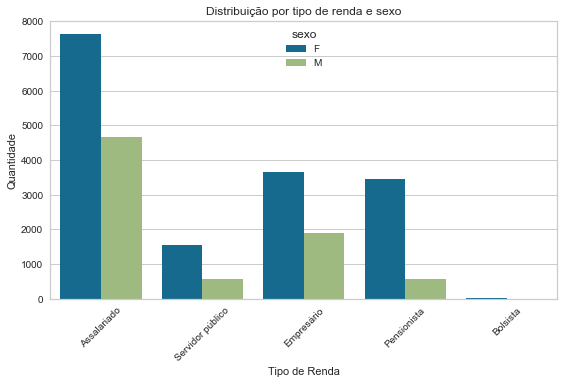

In [211]:
# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots()

# Plota a contagem de registros para cada categoria de 'tipo_renda', separado por 'sexo'
sns.countplot(x='tipo_renda', data=df_treino, hue='sexo', ax=ax)

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45)

# Define o título e os rótulos dos eixos do gráfico
ax.set_title("Distribuição por tipo de renda e sexo")
ax.set_xlabel("Tipo de Renda")
ax.set_ylabel("Quantidade")

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()

# Exibe o gráfico
plt.show()


## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

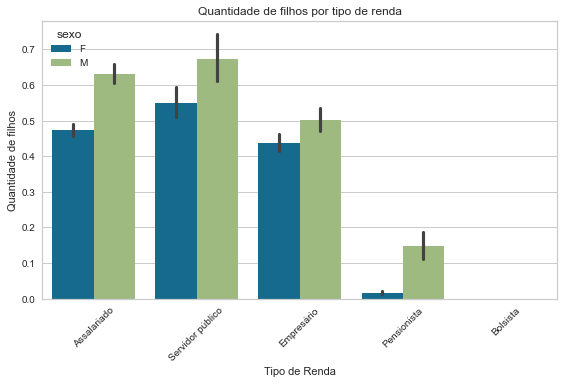

In [212]:
# Cria uma figura e um eixo para o gráfico
fig, ax = plt.subplots()

# Plota um gráfico de barras mostrando a média de 'qtd_filhos' para cada categoria de 'tipo_renda', separado por 'sexo'
sns.barplot(data=df_treino, x='tipo_renda', y='qtd_filhos', hue='sexo')

# Rotaciona os rótulos do eixo x para melhor visualização
plt.xticks(rotation=45)

# Define o título e os rótulos dos eixos do gráfico
ax.set_title("Quantidade de filhos por tipo de renda")
ax.set_xlabel("Tipo de Renda")
ax.set_ylabel("Quantidade de filhos")

# Ajusta o layout para evitar sobreposição de elementos
plt.tight_layout()

# Exibe o gráfico
plt.show()

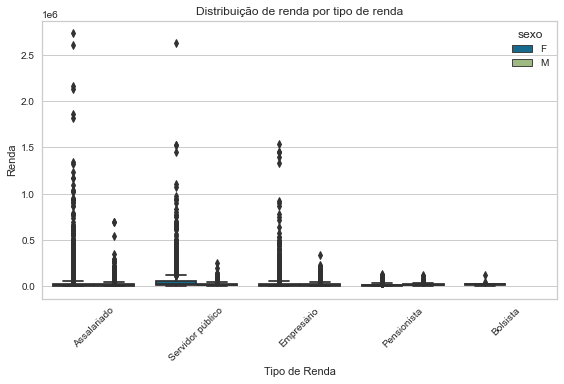

In [213]:
# Cria uma figura e um eixo para o gráfico 
fig, ax = plt.subplots()

# Plota um boxplot demonstrando a distribuição da rendapor quartis de cada sub-categoria da variável "Tipo de renda"
sns.boxplot(data=df_treino, x='tipo_renda', y='renda', hue='sexo')

# Rotaciona os rótulos do eixo x
plt.xticks(rotation=45)

# Define um título para o gráfico e o rótulo dos eixos
ax.set_title("Distribuição de renda por tipo de renda")
ax.set_xlabel("Tipo de Renda")
ax.set_ylabel("Renda")

# Ajusta o layout para ecitar sobrposição dos elementos
plt.tight_layout()

# Exibe o gráfico
plt.show()

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [214]:
metadados = atualizar_metadados(df_treino)
metadados

,dtype,n_missings,Valores únicos
sexo,object,0,2
posse_de_veiculo,object,0,2
posse_de_imovel,object,0,2
qtd_filhos,int64,0,8
tipo_renda,object,0,5
educacao,object,0,5
estado_civil,object,0,5
tipo_residencia,object,0,6
idade,int64,0,47
tempo_emprego,float64,4025,2781


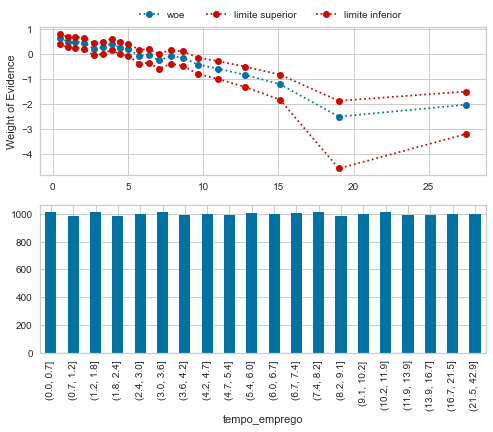

In [215]:
# Uso da função "biv_continua" para verificar a distribuição da variável nos agrupamentos criados dentro da função, e o valor de WOE para cada um dos clusters
biv_continua('tempo_emprego', 20, df_treino)

In [216]:
dict_bins = {}

# Cria uma cópia do dataframe de treino para evitar alterações no original
df_treino_1 = df_treino.copy()

# # Preenche todos os valores ausentes (NaN) do dataframe com -1
# df_treino_1.fillna(-1, inplace=True)

_, cat_tempo_emprego_bins = pd.qcut(
    df_treino_1["tempo_emprego"], q=20, duplicates="drop", precision=0, retbins=True
)


# Cria variáveis categóricas (bins) para variáveis contínuas usando qcut (quantis)
df_treino_1["cat_tempo_emprego"] = pd.cut(
    df_treino_1["tempo_emprego"],
    bins=cat_tempo_emprego_bins,
    precision=0,
    duplicates="drop",
)
df_treino_1["cat_tempo_emprego"] = (
    df_treino_1["cat_tempo_emprego"].cat.add_categories("Missing").fillna("Missing")
)

dict_bins['tempo_emprego'] = cat_tempo_emprego_bins

for col in ["qtd_filhos", "qt_pessoas_residencia", "renda"]:
    # Calcula os bins do treino
    _, bins = pd.qcut(
        df_treino_1[col], 20, retbins=True, precision=0, duplicates="drop"
    )
    cat = pd.cut(df_treino_1[col], bins=bins, precision=0, duplicates="drop")
    df_treino_1[f"cat_{col}"] = cat.cat.add_categories("Missing").fillna("Missing")
    dict_bins[col] = bins


# Remove as colunas originais contínuas e a coluna 'bom' do dataframe, pois agora serão usadas as versões categorizadas
df_treino_1.drop(
    columns=["renda", "qt_pessoas_residencia", "qtd_filhos", "tempo_emprego", "bom"],
    inplace=True,
)
# Atualiza o DataFrame de metadados para df_treino_1, incluindo tipos, missings e valores únicos
metadados_02 = atualizar_metadados(df_treino_1)

iv_dict = {}

# Para cada variável do DataFrame de metadados
for variavel in metadados_02.index.to_list():
    # Exclui variáveis contínuas originais e a target 'mau' do cálculo de IV
    if variavel not in [
        "tempo_emprego",
        "qtd_filhos",
        "qt_pessoas_residencia",
        "renda",
        "mau",
    ]:
        # Calcula o IV (Information Value) da variável para o target 'mau'
        iv_calculado = IV(df_treino_1[variavel], df_treino_1["mau"])
        iv_dict[variavel] = iv_calculado

# Adiciona a coluna 'IV' ao DataFrame de metadados, preenchendo com os valores calculados
metadados_02["IV"] = metadados_02.index.map(iv_dict)

iv_aprovado = metadados_02.loc[metadados_02["IV"] >= 0.02].index.to_list()

# Exibe o DataFrame de metadados atualizado, agora com a coluna IV
metadados_02

,dtype,n_missings,Valores únicos,IV
sexo,object,0,2,0.007790
posse_de_veiculo,object,0,2,0.000540
posse_de_imovel,object,0,2,0.004806
tipo_renda,object,0,5,0.012781
educacao,object,0,5,0.007305
estado_civil,object,0,5,0.004335
tipo_residencia,object,0,6,0.001928
idade,int64,0,47,0.062723
mau,int32,0,2,NaN
Mês,int64,0,12,0.274436


In [217]:
# Monta a fórmula para o modelo logístico, incluindo apenas variáveis aprovadas pelo IV
# Remove variáveis que não devem ser usadas como explicativas (indicadores de tempo, identificadores, etc)
formula = '+'.join([x for x in iv_aprovado if x not in ['mau', 'Ano', 'Ano_Trimestre', 'Dia do Mês', 'Dia_semana', 'Nome_mes', 'Mês']])

# Ajusta o modelo de regressão logística usando a fórmula criada e o dataframe df_treino_1
# O target é 'mau' e as variáveis explicativas são as selecionadas na fórmula
modelo = smf.logit(f'mau ~ {formula}', df_treino_1).fit()

         Current function value: 0.194530
         Iterations: 35


In [218]:
# Seleciona o cliente
cliente = df_treino_1.iloc[[30]]  # << note os colchetes duplos para manter como DataFrame

# Aplica a mesma transformação da fórmula
X_cliente = dmatrix(modelo.model.data.design_info, cliente, return_type='dataframe')

# Calcula a previsão
z = np.dot(X_cliente, modelo.params)
probabilidade = 1 / (1 + np.exp(-z))

print(f"Probabilidade prevista de inadimplência: {float(probabilidade):.2%}")



Probabilidade prevista de inadimplência: 13.15%


## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [219]:
# Cria uma cópia da base de teste (out of time) para não alterar o original
df_teste = df_oot.copy()

# Para cada variável contínua, aplica os mesmos bins usados no treino
for col in ["tempo_emprego", "qtd_filhos", "qt_pessoas_residencia", "renda"]:
    # Aplica os bins definidos no treino para categorizar os dados da base de teste
    cat = pd.cut(df_teste[col], bins=dict_bins[f'{col}'], precision=0, duplicates="drop")
    df_teste[f'cat_{col}'] = cat
    # Adiciona a categoria "Missing" para valores ausentes
    df_teste[f"cat_{col}"] = cat.cat.add_categories("Missing").fillna("Missing")
    
# Remove as colunas originais contínuas, pois agora serão usadas as versões categorizadas
df_teste.drop(columns=['renda', 'qt_pessoas_residencia', 'qtd_filhos', 'tempo_emprego'], inplace=True)

# Avalia o desempenho do modelo na base de treino
print('Performance do modelo na base de treino:\n')
poder_de_predicao(df_treino_1, modelo)

# Avalia o desempenho do modelo na base de teste (out of time)
print('\nPerformance do modelo na base de teste:\n')
poder_de_predicao(df_teste, modelo)

Performance do modelo na base de treino:

Acurácia: 72.3% 
auc: 76.9% 
GINI: 53.9%
KS: 41.0%

Performance do modelo na base de teste:

Acurácia: 39.6% 
auc: 72.0% 
GINI: 44.1%
KS: 34.1%


In [220]:
df_treino.columns.to_list()

['data_ref',
 'index',
 'sexo',
 'posse_de_veiculo',
 'posse_de_imovel',
 'qtd_filhos',
 'tipo_renda',
 'educacao',
 'estado_civil',
 'tipo_residencia',
 'idade',
 'tempo_emprego',
 'qt_pessoas_residencia',
 'renda',
 'mau',
 'Mês',
 'Nome_mes',
 'Dia_semana',
 'Dia do mês',
 'Ano_Trimestre',
 'Ano',
 'tempo_emprego_missing',
 'bom']

# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

In [221]:
from sklearn.preprocessing import StandardScaler

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [222]:
df_treino_2 = df_treino.copy()
X_treino = df_treino_2.drop(columns=['mau', 'bom'])

In [223]:
from sklearn.base import BaseEstimator, TransformerMixin

class ZeroStructuralTreatment(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        _df = X.copy()
        mask = (_df.isna().any(axis=1)) & (_df['tipo_renda'] == 'Pensionista')
        _df.loc[mask, 'tempo_emprego'] = -1
        return _df

# ------------------------------------------------#
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

class OutlierTreatment(BaseEstimator, TransformerMixin):
    def __init__(self, contamination=0.1, random_state=42):
        self.contamination = contamination
        self.random_state = random_state
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        _df = X.copy()
        _df_scaled = StandardScaler().fit_transform(_df)
        iso = IsolationForest(contamination=self.contamination, random_state=self.random_state)
        pred = iso.fit_predict(_df_scaled)
        _df['outlier_iforest'] = (pred == -1)
        return _df


# ------------------------------------------------#

def feature_importance(_modelo):
    # Extrai os coeficientes absolutos do modelo e ordena em ordem decrescente
    coefs = _modelo.params.abs().sort_values(ascending=False)
    
    # Transforma os coeficientes em um DataFrame para facilitar manipulação/visualização
    valores_dos_coeficientes = coefs.to_frame()

    # P-values associados aos coeficientes (importância estatística)
    pvalues = _modelo.pvalues

    # Define limites mínimos para considerar uma variável relevante
    coef_threshold = 0.1     # coeficiente absoluto mínimo para relevância
    pval_threshold = 0.05    # nível usual de significância estatística

    # Cria uma máscara booleana combinando os dois critérios: coeficiente e p-value
    mask = (coefs > coef_threshold) & (pvalues < pval_threshold)

    # Filtra as variáveis que passam nos dois critérios e retorna seus nomes
    variaveis_filtradas = coefs[mask].index.tolist()

    # Mostra no console o número total de variáveis no modelo
    print(f'O número de variáveis presentes no modelo é de: {len(_modelo.params.index.to_list())}')
    
    # Mostra quantas variáveis passaram no filtro de coeficiente e p-valor
    print(f'Após o processo de filtragem das variáveis, restaram: {len(variaveis_filtradas)}')
    
    # Cria um gráfico de barras dos coeficientes absolutos para visualização da importância
    fig, ax = plt.subplots(figsize=(15,8))
    coefs.plot(kind='bar', ax=ax)
    ax.set_title('Importância das variáveis (coeficientes absolutos)')
    plt.show()
    
    # Retorna o DataFrame com os valores dos coeficientes e a lista das variáveis filtradas
    return valores_dos_coeficientes, variaveis_filtradas

# ------------------------------------------------#


from sklearn.decomposition import PCA
from sklearn.base import BaseEstimator, TransformerMixin
import pandas as pd  # necessário para retornar DataFrame no transform

class PCAConverter(BaseEstimator, TransformerMixin):
    # Classe customizada para aplicar PCA dentro de um pipeline scikit-learn
    
    def __init__(self, n_components=5):
        # Inicializa o conversor PCA com número desejado de componentes principais
        self.n_components = n_components
        self.pca = None  # atributo para armazenar o objeto PCA após o fit
    
    def fit(self, X, y=None):
        # Ajusta o modelo PCA aos dados X
        # Garante que n_components não seja maior que o número de colunas de X
        n_components = min(self.n_components, X.shape[1])
        
        # Cria o objeto PCA com n_components ajustado
        self.pca = PCA(n_components=n_components)
        
        # Realiza o fit do PCA nos dados de entrada
        self.pca.fit(X)
        
        # Retorna self para permitir encadeamento em pipelines
        return self
    
    def transform(self, X):
        # Transforma os dados de entrada aplicando a decomposição PCA
        
        # Aplica a transformação PCA
        componentes = self.pca.transform(X)
        
        # Cria nomes para as colunas do DataFrame resultante (PC1, PC2, ...)
        colunas = [f'PC{i+1}' for i in range(componentes.shape[1])]
        
        # Retorna um DataFrame com os componentes principais, mantendo os índices originais
        return pd.DataFrame(componentes, columns=colunas, index=X.index)
    
# ------------------------------------------------#

class DummyConverter(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.colunas_para_remover = [
            "Mês", "Dia_semana", "Dia do mês",
            "Ano_Trimestre", "Ano", "data_ref", "index"
        ]
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        _df = X.copy()
        _df.drop(columns=[c for c in self.colunas_para_remover if c in _df.columns], inplace=True)
        return pd.get_dummies(_df, dtype=int)


# ------------------------------------------------#


In [224]:
df_treino_2.loc[(df_treino_2.isna().any(axis=1)) & (df_treino_2['tipo_renda'] == 'Pensionista'), 'tempo_emprego'] = -1

In [225]:
tratar_zero = ZeroStructuralTreatment()

X_treino = tratar_zero.fit_transform(X_treino)

In [226]:
conversao_para_dummies = DummyConverter()
X_treino_dummies = conversao_para_dummies.fit_transform(X_treino)
df_treino2_dummies = conversao_para_dummies.fit_transform(df_treino_2)

### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

In [227]:
X_treino.loc[X_treino['tipo_renda'] == 'Pensionista']

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,Mês,Nome_mes,Dia_semana,Dia do mês,Ano_Trimestre,Ano,tempo_emprego_missing
4144,2015-01-01,5575,F,N,N,0,Pensionista,Médio,Casado,Casa,60,-1.0,2.0,5650.57,1,Janeiro,Quinta-feira,1,2015-T1,2015,1
1414,2015-01-01,10312,F,N,S,0,Pensionista,Médio,Casado,Casa,52,-1.0,2.0,2186.41,1,Janeiro,Quinta-feira,1,2015-T1,2015,1
12609,2015-01-01,6882,F,N,S,0,Pensionista,Médio,Casado,Casa,65,-1.0,2.0,9278.25,1,Janeiro,Quinta-feira,1,2015-T1,2015,1
12144,2015-01-01,9668,F,N,S,0,Pensionista,Médio,Casado,Casa,65,-1.0,2.0,5576.31,1,Janeiro,Quinta-feira,1,2015-T1,2015,1
15118,2015-01-01,10010,M,N,S,0,Pensionista,Superior completo,Casado,Casa,67,-1.0,2.0,6789.94,1,Janeiro,Quinta-feira,1,2015-T1,2015,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
597262,2015-12-01,9624,F,N,S,0,Pensionista,Médio,Casado,Casa,52,-1.0,2.0,6310.69,12,Dezembro,Terça-feira,1,2015-T4,2015,1
552522,2015-12-01,3026,F,N,S,0,Pensionista,Médio,Viúvo,Casa,55,-1.0,1.0,4467.10,12,Dezembro,Terça-feira,1,2015-T4,2015,1
574676,2015-12-01,305,F,N,N,0,Pensionista,Médio,Viúvo,Casa,59,-1.0,1.0,2271.80,12,Dezembro,Terça-feira,1,2015-T4,2015,1
593741,2015-12-01,8513,F,N,N,0,Pensionista,Médio,Casado,Casa,59,-1.0,2.0,12879.71,12,Dezembro,Terça-feira,1,2015-T4,2015,1


#### Tratamento de outliers se valendo do Z-Score

In [228]:
# 1. Padronização das variáveis numéricas usando StandardScaler
scaler = StandardScaler()
X_treino_scaled = pd.DataFrame(
    scaler.fit_transform(X_treino_dummies),  # Aplica a padronização (média=0, desvio=1)
    columns=X_treino_dummies.columns,        # Mantém os nomes das colunas originais
    index=X_treino_dummies.index             # Mantém os índices originais
)

# Seleciona as colunas contínuas para análise de outliers
cont_cols = ['qtd_filhos', 'idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda']

# Calcula o valor absoluto do z-score para cada coluna contínua
z_scores = np.abs(X_treino_scaled[cont_cols])

# Remove linhas que possuem algum z-score >= 3 (consideradas outliers)
X_treino_sem_outliers = X_treino_dummies[(z_scores < 3).all(axis=1)]

# Cria uma máscara para identificar linhas com pelo menos um outlier
mask_outliers = ~(z_scores < 3).all(axis=1)  # True para linhas com outlier

# Cria uma máscara para identificar linhas com pelo menos um NaN
mask_nan = z_scores.isna().any(axis=1)       # True para linhas com NaN

# Seleciona linhas que possuem outliers ou NaN
X_treino_com_outliers = X_treino_dummies[mask_outliers | mask_nan]

# Exibe o DataFrame sem outliers
X_treino_sem_outliers


,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,tempo_emprego_missing,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,posse_de_imovel_N,posse_de_imovel_S,tipo_renda_Assalariado,tipo_renda_Bolsista,tipo_renda_Empresário,tipo_renda_Pensionista,tipo_renda_Servidor público,educacao_Fundamental,educacao_Médio,educacao_Pós graduação,educacao_Superior completo,educacao_Superior incompleto,estado_civil_Casado,estado_civil_Separado,estado_civil_Solteiro,estado_civil_União,estado_civil_Viúvo,tipo_residencia_Aluguel,tipo_residencia_Casa,tipo_residencia_Com os pais,tipo_residencia_Comunitário,tipo_residencia_Estúdio,tipo_residencia_Governamental,Nome_mes_Abril,Nome_mes_Agosto,Nome_mes_Dezembro,Nome_mes_Fevereiro,Nome_mes_Janeiro,Nome_mes_Julho,Nome_mes_Junho,Nome_mes_Maio,Nome_mes_Março,Nome_mes_Novembro,Nome_mes_Outubro,Nome_mes_Setembro
33553,2,40,3.454795,4.0,3036.39,0,1,0,1,0,0,1,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
9427,0,43,24.621918,1.0,23128.66,0,1,0,1,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
199,0,41,6.049315,1.0,4435.27,0,0,1,1,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
12447,0,27,3.035616,1.0,2931.83,0,1,0,0,1,1,0,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
39489,1,29,8.673973,2.0,4101.53,0,1,0,1,0,1,0,0,0,1,0,0,0,1,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583582,0,48,2.410959,2.0,622.68,0,1,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
581702,0,52,12.339726,2.0,16145.02,0,1,0,0,1,0,1,1,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
588237,1,41,5.646575,3.0,4072.03,0,1,0,1,0,0,1,0,0,0,0,1,0,1,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0
572358,0,60,-1.000000,1.0,1436.45,1,1,0,1,0,0,1,0,0,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0


### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

In [229]:
from pycaret.classification import *

In [230]:
#forçando a variável qnt de filhos como numérica
df_treino2_dummies.qtd_filhos = df_treino2_dummies.qtd_filhos.astype(float)
df_treino2_dummies = df_treino2_dummies.drop(columns=['bom'])
exp_lr = setup(data=df_treino2_dummies, target='mau', session_id=123)
lr = create_model('lr')
modelo_02 = create_model('lr')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9429,0.7154,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9429,0.7391,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9429,0.7185,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9423,0.7333,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9423,0.7639,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9423,0.7399,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9423,0.7416,0.0000,0.0000,0.0000,0.0000,0.0000
7,0.9423,0.7190,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9423,0.7579,0.0000,0.0000,0.0000,0.0000,0.0000


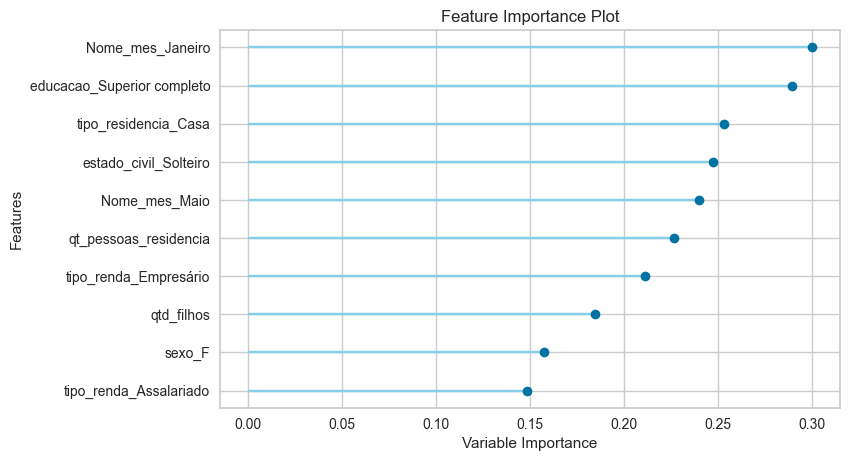

In [231]:
plot_model(modelo_02, plot='feature')

O número de variáveis presentes no modelo é de: 42
Após o processo de filtragem das variáveis, restaram: 21


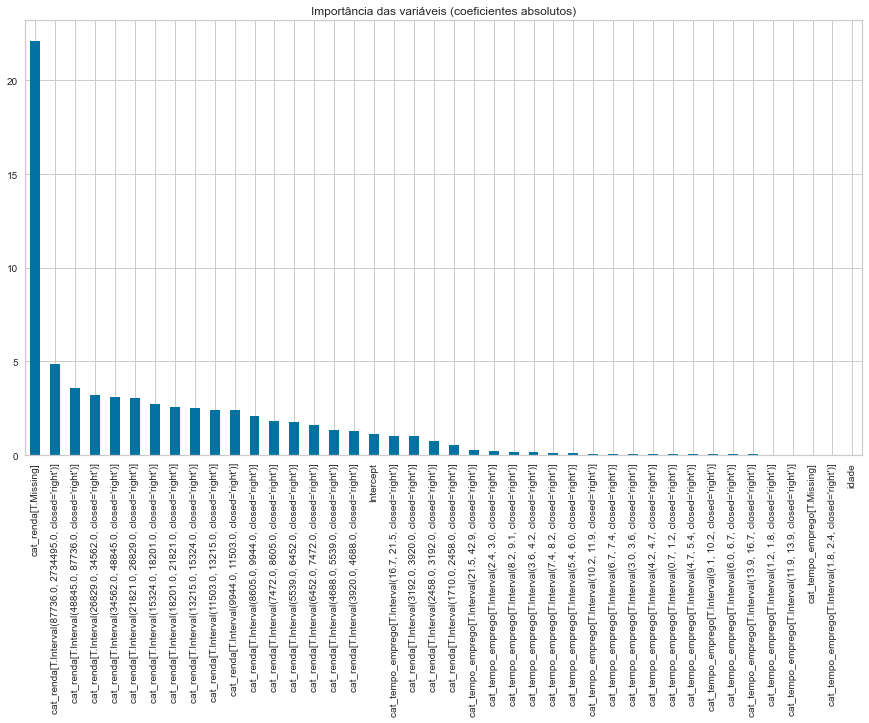

["cat_renda[T.Interval(87736.0, 2734495.0, closed='right')]",
 "cat_renda[T.Interval(48845.0, 87736.0, closed='right')]",
 "cat_renda[T.Interval(26829.0, 34562.0, closed='right')]",
 "cat_renda[T.Interval(34562.0, 48845.0, closed='right')]",
 "cat_renda[T.Interval(21821.0, 26829.0, closed='right')]",
 "cat_renda[T.Interval(15324.0, 18201.0, closed='right')]",
 "cat_renda[T.Interval(18201.0, 21821.0, closed='right')]",
 "cat_renda[T.Interval(13215.0, 15324.0, closed='right')]",
 "cat_renda[T.Interval(11503.0, 13215.0, closed='right')]",
 "cat_renda[T.Interval(9944.0, 11503.0, closed='right')]",
 "cat_renda[T.Interval(8605.0, 9944.0, closed='right')]",
 "cat_renda[T.Interval(7472.0, 8605.0, closed='right')]",
 "cat_renda[T.Interval(5539.0, 6452.0, closed='right')]",
 "cat_renda[T.Interval(6452.0, 7472.0, closed='right')]",
 "cat_renda[T.Interval(4688.0, 5539.0, closed='right')]",
 "cat_renda[T.Interval(3920.0, 4688.0, closed='right')]",
 'Intercept',
 "cat_tempo_emprego[T.Interval(16.7, 

In [232]:
feature_importance(modelo)[1]

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [233]:
conversao_pca = PCAConverter()
pca_treino_dummies = conversao_pca.fit_transform(X_treino_dummies)

In [234]:
pca_treino_dummies

,PC1,PC2,PC3,PC4,PC5
33553,-23594.074392,-3.281822,2.113471,2.133092,1.176771
9427,-3501.803408,-2.803906,-18.288404,-1.755912,0.516058
199,-22195.194258,-2.484366,-0.481908,-1.535210,-0.314888
12447,-23698.634616,-16.031079,4.053468,-2.027954,-0.425084
39489,-22528.934332,-14.721119,-1.729366,-0.747865,0.962491
...,...,...,...,...,...
583582,-26007.784306,4.883839,2.140537,-0.341313,0.339341
581702,-10485.443812,7.549339,-7.459392,-0.016069,-0.607045
588237,-22558.434277,-2.487482,-0.111960,0.788501,0.984569
572358,-25194.014269,17.269825,4.248882,-0.880742,0.559363


### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [235]:
X_treino_dummies

,qtd_filhos,idade,tempo_emprego,qt_pessoas_residencia,renda,tempo_emprego_missing,sexo_F,sexo_M,posse_de_veiculo_N,posse_de_veiculo_S,...,Nome_mes_Dezembro,Nome_mes_Fevereiro,Nome_mes_Janeiro,Nome_mes_Julho,Nome_mes_Junho,Nome_mes_Maio,Nome_mes_Março,Nome_mes_Novembro,Nome_mes_Outubro,Nome_mes_Setembro
33553,2,40,3.454795,4.0,3036.39,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
9427,0,43,24.621918,1.0,23128.66,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
199,0,41,6.049315,1.0,4435.27,0,0,1,1,0,...,0,0,1,0,0,0,0,0,0,0
12447,0,27,3.035616,1.0,2931.83,0,1,0,0,1,...,0,0,1,0,0,0,0,0,0,0
39489,1,29,8.673973,2.0,4101.53,0,1,0,1,0,...,0,0,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
583582,0,48,2.410959,2.0,622.68,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
581702,0,52,12.339726,2.0,16145.02,0,1,0,0,1,...,1,0,0,0,0,0,0,0,0,0
588237,1,41,5.646575,3.0,4072.03,0,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0
572358,0,60,-1.000000,1.0,1436.45,1,1,0,1,0,...,1,0,0,0,0,0,0,0,0,0


### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [236]:
pipe_conversao_para_dummies = pd.get_dummies(
    X_treino.drop(
        columns=[
            "Mês",
            "Dia_semana",
            "Dia do mês",
            "Ano_Trimestre",
            "Ano",
            "data_ref",
            "index",
        ]
    ),
    dtype=int,
)
pipe_removendo_nulos = ZeroStructuralTreatment()
pipe_tratando_outliers = OutlierTreatment()
pipe_conversao_pca = PCAConverter()



In [237]:
from sklearn.pipeline import Pipeline

pipe = Pipeline(
    steps=[
        ("Null_treatment", ZeroStructuralTreatment()),
        ("Dummies_conversion", DummyConverter()),
        ("Outlier_Treatment", OutlierTreatment()),
        ('pca', PCAConverter()),
    ]
)

pipe.fit_transform(X_treino)

,PC1,PC2,PC3,PC4,PC5
33553,-23594.074392,-3.281690,2.113402,2.136352,1.186280
9427,-3501.803408,-2.803757,-18.288470,-1.754291,0.513679
199,-22195.194258,-2.484235,-0.481971,-1.534722,-0.320898
12447,-23698.634616,-16.030937,4.053387,-2.027440,-0.437045
39489,-22528.934332,-14.720975,-1.729446,-0.746148,0.952858
...,...,...,...,...,...
583582,-26007.784306,4.883960,2.140482,-0.340393,0.326501
581702,-10485.443812,7.549470,-7.459446,-0.014412,-0.597605
588237,-22558.434277,-2.487349,-0.112027,0.791470,0.993008
572358,-25194.014269,17.269934,4.248843,-0.879317,0.561687


# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [238]:
import pandas as pd

df = pd.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [239]:
from pycaret.classification import *
df.qtd_filhos = df.qtd_filhos.astype('float')
exp_lightgbm = setup(data = df, target = 'mau', session_id=123) 

,Description,Value
0,session_id,123
1,Target,mau
2,Target Type,Binary
3,Label Encoded,"False: 0, True: 1"
4,Original Data,"(750000, 15)"
5,Missing Values,True
6,Numeric Features,6
7,Categorical Features,7
8,Ordinal Features,False
9,High Cardinality Features,False


In [240]:
lgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9223,0.7778,0.0300,0.5491,0.0569,0.0492,0.1149
1,0.9221,0.7818,0.0241,0.5351,0.0462,0.0397,0.1013
2,0.9224,0.7776,0.0263,0.5684,0.0503,0.0437,0.1101
3,0.9222,0.7801,0.0254,0.5389,0.0484,0.0417,0.1043
4,0.9222,0.7825,0.0249,0.5484,0.0476,0.0411,0.1045
5,0.9225,0.7832,0.0302,0.5741,0.0574,0.0500,0.1188
6,0.9222,0.7802,0.0285,0.5367,0.0542,0.0467,0.1103
7,0.9220,0.7781,0.0244,0.5155,0.0466,0.0398,0.0993
8,0.9227,0.7786,0.0341,0.5932,0.0646,0.0565,0.1290


In [241]:
tuned_lgbm = tune_model(lgbm)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9223,0.7781,0.0310,0.5427,0.0586,0.0506,0.1158
1,0.9221,0.7817,0.0249,0.5340,0.0475,0.0409,0.1027
2,0.9225,0.7790,0.0273,0.5803,0.0522,0.0455,0.1137
3,0.9221,0.7812,0.0244,0.5348,0.0466,0.0401,0.1017
4,0.9224,0.7837,0.0280,0.5693,0.0535,0.0465,0.1138
5,0.9224,0.7840,0.0300,0.5668,0.0570,0.0495,0.1173
6,0.9222,0.7811,0.0293,0.5381,0.0555,0.0478,0.1120
7,0.9220,0.7787,0.0249,0.5152,0.0475,0.0405,0.1002
8,0.9228,0.7794,0.0349,0.5958,0.0659,0.0577,0.1307


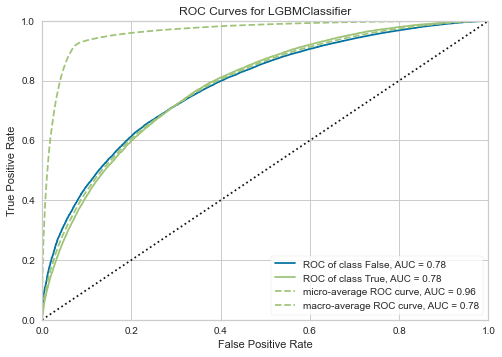

In [242]:
plot_model(tuned_lgbm, plot = 'auc')

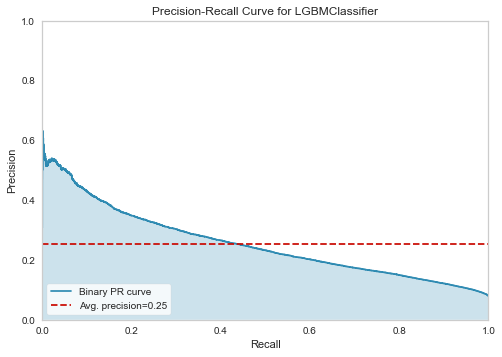

In [243]:
plot_model(tuned_lgbm, plot = 'pr')

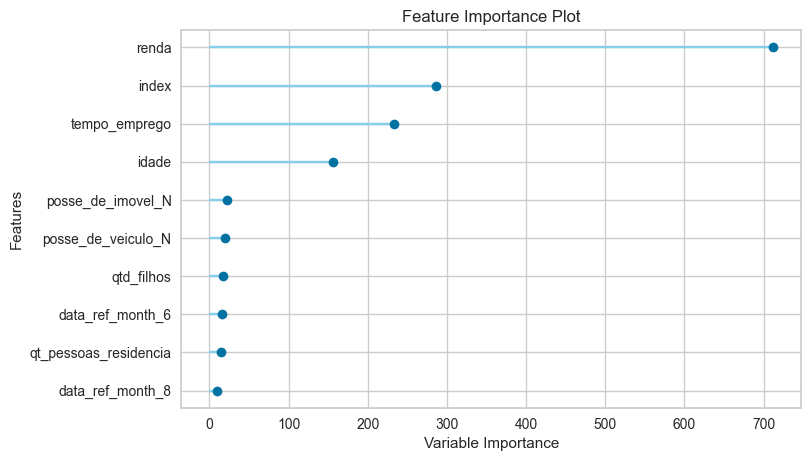

In [244]:
plot_model(tuned_lgbm, plot='feature')

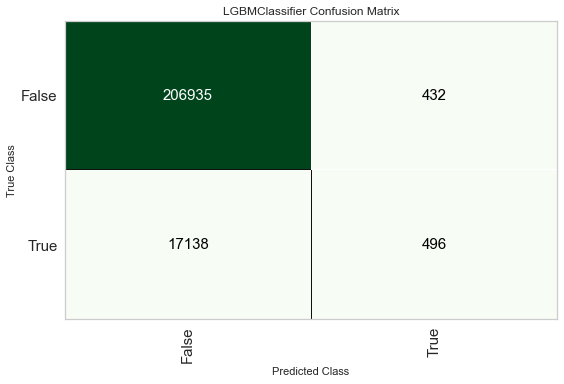

In [245]:
plot_model(tuned_lgbm, plot = 'confusion_matrix')

In [246]:
final_model = finalize_model(tuned_lgbm)
pipeline = get_config('prep_pipe')  # pipeline de pré-processamento

### Salvar o arquivo do modelo treinado

# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.